In [ ]:
!pip install pandas matplotlib seaborn

# Analisis de Hiperparametros NER

Este notebook analiza los resultados del grid search de NER guardados en `../artifacts/ner/hyperparam_results.json`.

El objetivo es comparar configuraciones, identificar que hiperparametros afectan mas al rendimiento y decidir que modelo conviene conservar como mejor candidato.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

ROOT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "analysis" else Path.cwd().resolve()
OUTPUT_DIR = ROOT_DIR / "analysis" / "artifact_ner_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Carga de resultados


In [2]:
results_path = ROOT_DIR / "artifacts" / "ner" / "hyperparam_results.json"
if not results_path.exists():
    raise FileNotFoundError(f"No existe {results_path}")

results = json.loads(results_path.read_text(encoding="utf-8"))
if not isinstance(results, list) or not results:
    raise ValueError("hyperparam_results.json esta vacio o no contiene una lista")

print(f"Total de configuraciones registradas: {len(results)}")
print("Claves del primer resultado:", sorted(results[0].keys()))
print("Claves de config:", sorted(results[0]["config"].keys()))


Total de configuraciones registradas: 36
Claves del primer resultado: ['best_epoch', 'best_val_loss', 'best_val_token_f1_micro', 'config', 'run_dir', 'status']
Claves de config: ['artifacts_dir', 'batch_size', 'data_path', 'epochs', 'freeze_backbone', 'learning_rate', 'output_dir']


## 2. Preparar DataFrame


In [3]:
rows = []
for item in results:
    row = dict(item["config"])
    row["run_dir"] = item.get("run_dir")
    row["best_val_loss"] = item.get("best_val_loss")
    row["best_val_token_f1_micro"] = item.get("best_val_token_f1_micro")
    row["best_epoch"] = item.get("best_epoch")
    row["status"] = item.get("status")
    row["error"] = item.get("error")
    rows.append(row)

df = pd.DataFrame(rows)
df["freeze_backbone"] = df["freeze_backbone"].astype(str)
df.head()

,data_path,artifacts_dir,output_dir,batch_size,epochs,learning_rate,freeze_backbone,run_dir,best_val_loss,best_val_token_f1_micro,best_epoch,status,error
0,/home/hegarc04/pln/fdi-pln-2602/p5/data/ner_da...,artifacts/llm/best_general,artifacts/ner,8,4,0.0010,True,artifacts/ner/runs/20260521-205820-566568,0.367831,0.915556,4,completed,None
1,/home/hegarc04/pln/fdi-pln-2602/p5/data/ner_da...,artifacts/llm/best_general,artifacts/ner,8,4,0.0010,False,artifacts/ner/runs/20260521-205822-782503,0.106325,0.971418,3,completed,None
2,/home/hegarc04/pln/fdi-pln-2602/p5/data/ner_da...,artifacts/llm/best_general,artifacts/ner,8,4,0.0005,True,artifacts/ner/runs/20260521-205823-689750,0.601920,0.839690,4,completed,None
3,/home/hegarc04/pln/fdi-pln-2602/p5/data/ner_da...,artifacts/llm/best_general,artifacts/ner,8,4,0.0005,False,artifacts/ner/runs/20260521-205824-883604,0.108057,0.972175,4,completed,None
4,/home/hegarc04/pln/fdi-pln-2602/p5/data/ner_da...,artifacts/llm/best_general,artifacts/ner,8,8,0.0010,True,artifacts/ner/runs/20260521-205826-738076,0.280760,0.937384,8,completed,None


In [4]:
completed = df[df["status"] == "completed"].copy()
failed = df[df["status"] != "completed"].copy()

print(f"Configuraciones completadas: {len(completed)}")
print(f"Configuraciones fallidas: {len(failed)}")

if not failed.empty:
    display(
        failed[["batch_size", "epochs", "learning_rate", "freeze_backbone", "error"]]
    )

Configuraciones completadas: 36
Configuraciones fallidas: 0


## 3. Ranking de mejores configuraciones


In [5]:
ranking = completed.sort_values(
    by=["best_val_token_f1_micro", "best_val_loss"],
    ascending=[False, True],
).reset_index(drop=True)

ranking[
    [
        "batch_size",
        "epochs",
        "learning_rate",
        "freeze_backbone",
        "best_epoch",
        "best_val_token_f1_micro",
        "best_val_loss",
        "run_dir",
    ]
].head(10)

,batch_size,epochs,learning_rate,freeze_backbone,best_epoch,best_val_token_f1_micro,best_val_loss,run_dir
0,32,8,0.0010,False,6,0.983058,0.082086,artifacts/ner/runs/20260521-205925-638984
1,32,16,0.0010,False,6,0.983058,0.082086,artifacts/ner/runs/20260521-205935-611740
2,16,16,0.0010,False,12,0.977308,0.109111,artifacts/ner/runs/20260521-205909-748875
3,32,8,0.0005,False,7,0.977023,0.084120,artifacts/ner/runs/20260521-205928-476133
4,32,16,0.0005,False,7,0.977023,0.084120,artifacts/ner/runs/20260521-205940-894287
5,16,8,0.0010,False,6,0.976686,0.104568,artifacts/ner/runs/20260521-205900-708209
6,32,4,0.0010,False,4,0.976610,0.091553,artifacts/ner/runs/20260521-205922-007438
7,32,4,0.0005,False,4,0.973924,0.123388,artifacts/ner/runs/20260521-205923-544952
8,16,4,0.0010,False,4,0.972956,0.109505,artifacts/ner/runs/20260521-205855-427559
9,8,16,0.0005,False,15,0.972776,0.137842,artifacts/ner/runs/20260521-205851-389972


In [6]:
best = ranking.iloc[0]
print("Mejor configuracion encontrada:")
print(f"  batch_size={best['batch_size']}")
print(f"  epochs={best['epochs']}")
print(f"  learning_rate={best['learning_rate']}")
print(f"  freeze_backbone={best['freeze_backbone']}")
print(f"  best_epoch={best['best_epoch']}")
print(f"  val_token_f1_micro={best['best_val_token_f1_micro']:.4f}")
print(f"  val_loss={best['best_val_loss']:.4f}")
print(f"  run_dir={best['run_dir']}")

Mejor configuracion encontrada:
  batch_size=32
  epochs=8
  learning_rate=0.001
  freeze_backbone=False
  best_epoch=6
  val_token_f1_micro=0.9831
  val_loss=0.0821
  run_dir=artifacts/ner/runs/20260521-205925-638984


In [ ]:
top10_plot = ranking.head(10).copy()
labels = [
    f"bs={row.batch_size}, ep={row.epochs}, lr={row.learning_rate}, freeze={row.freeze_backbone}"
    for row in top10_plot.itertuples()
]
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_plot, x="best_val_token_f1_micro", y=labels, orient="h")
plt.title("Top 10 configuraciones NER")
plt.xlabel("best_val_token_f1_micro")
plt.ylabel("configuracion")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top10_ner_configs.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Resumen por hiperparametro


In [7]:
summary_by_freeze = (
    completed.groupby("freeze_backbone")
    .agg(
        mean_f1=("best_val_token_f1_micro", "mean"),
        max_f1=("best_val_token_f1_micro", "max"),
        mean_loss=("best_val_loss", "mean"),
        count=("best_val_token_f1_micro", "count"),
    )
    .sort_values("max_f1", ascending=False)
)
summary_by_freeze

,mean_f1,max_f1,mean_loss,count
freeze_backbone,,,,
False,0.974856,0.983058,0.104755,18
True,0.834365,0.940302,0.570548,18


In [8]:
summary_by_lr = (
    completed.groupby("learning_rate")
    .agg(
        mean_f1=("best_val_token_f1_micro", "mean"),
        max_f1=("best_val_token_f1_micro", "max"),
        mean_loss=("best_val_loss", "mean"),
        count=("best_val_token_f1_micro", "count"),
    )
    .sort_values("max_f1", ascending=False)
)
summary_by_lr

,mean_f1,max_f1,mean_loss,count
learning_rate,,,,
0.0010,0.931013,0.983058,0.269705,18
0.0005,0.878207,0.977023,0.405597,18


In [9]:
summary_by_batch = (
    completed.groupby("batch_size")
    .agg(
        mean_f1=("best_val_token_f1_micro", "mean"),
        max_f1=("best_val_token_f1_micro", "max"),
        mean_loss=("best_val_loss", "mean"),
        count=("best_val_token_f1_micro", "count"),
    )
    .sort_values("max_f1", ascending=False)
)
summary_by_batch

,mean_f1,max_f1,mean_loss,count
batch_size,,,,
32,0.853365,0.983058,0.459776,12
16,0.917003,0.977308,0.313670,12
8,0.943462,0.972776,0.239509,12


In [10]:
summary_by_epochs = (
    completed.groupby("epochs")
    .agg(
        mean_f1=("best_val_token_f1_micro", "mean"),
        max_f1=("best_val_token_f1_micro", "max"),
        mean_loss=("best_val_loss", "mean"),
        count=("best_val_token_f1_micro", "count"),
    )
    .sort_values("max_f1", ascending=False)
)
summary_by_epochs

,mean_f1,max_f1,mean_loss,count
epochs,,,,
8,0.917322,0.983058,0.310592,12
16,0.948574,0.983058,0.227912,12
4,0.847935,0.976610,0.474450,12


## 5. Graficas


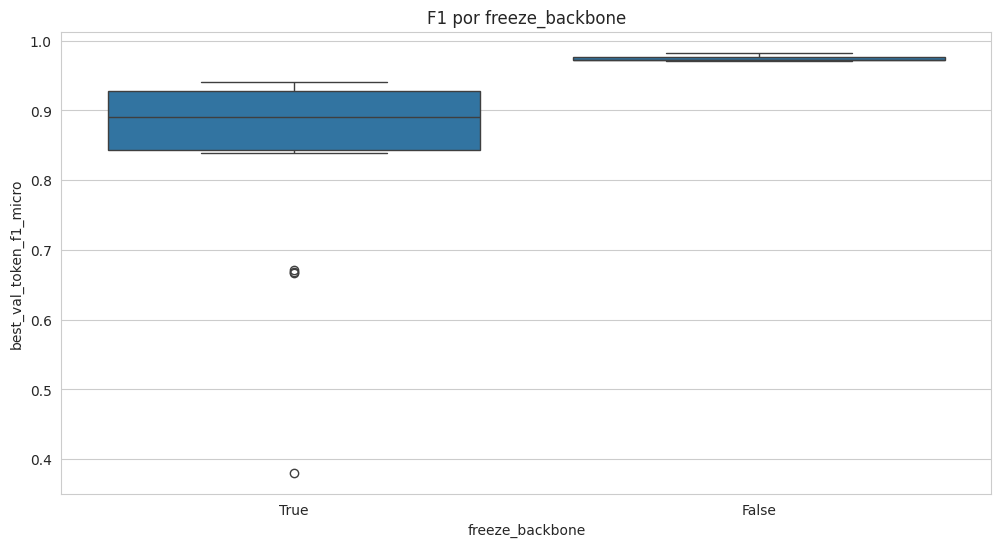

In [11]:
plt.figure()
sns.boxplot(data=completed, x="freeze_backbone", y="best_val_token_f1_micro")
plt.title("F1 por freeze_backbone")
plt.xlabel("freeze_backbone")
plt.ylabel("best_val_token_f1_micro")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "f1_by_freeze_backbone.png", dpi=180)
plt.show()

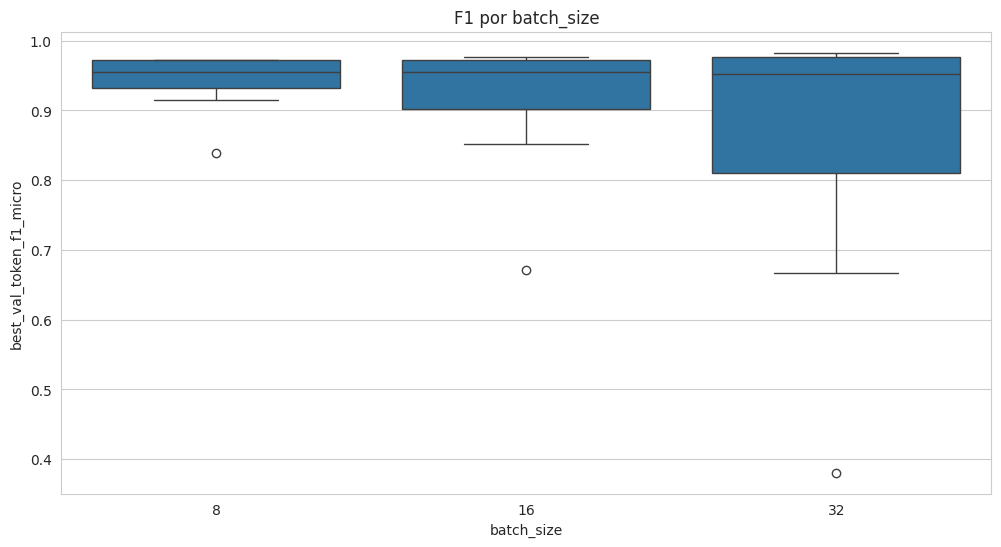

In [12]:
plt.figure()
sns.boxplot(data=completed, x="batch_size", y="best_val_token_f1_micro")
plt.title("F1 por batch_size")
plt.xlabel("batch_size")
plt.ylabel("best_val_token_f1_micro")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "f1_by_batch_size.png", dpi=180)
plt.show()

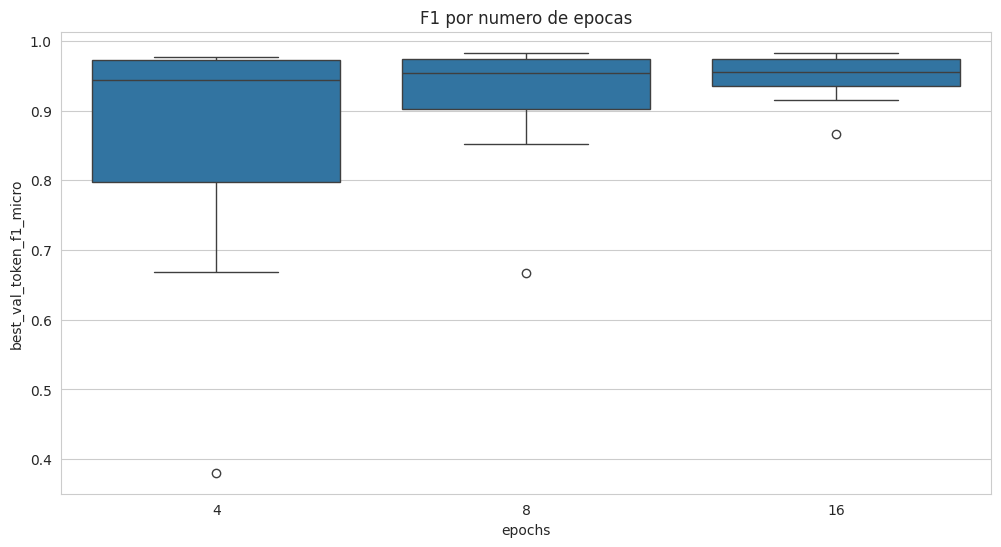

In [13]:
plt.figure()
sns.boxplot(data=completed, x="epochs", y="best_val_token_f1_micro")
plt.title("F1 por numero de epocas")
plt.xlabel("epochs")
plt.ylabel("best_val_token_f1_micro")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "f1_by_epochs.png", dpi=180)
plt.show()

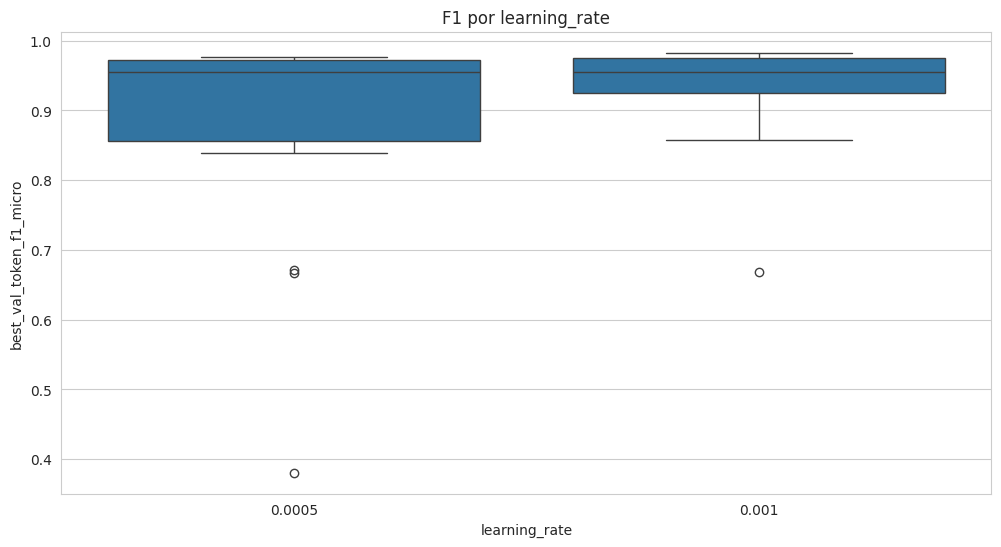

In [14]:
plt.figure()
sns.boxplot(data=completed, x="learning_rate", y="best_val_token_f1_micro")
plt.title("F1 por learning_rate")
plt.xlabel("learning_rate")
plt.ylabel("best_val_token_f1_micro")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "f1_by_learning_rate.png", dpi=180)
plt.show()

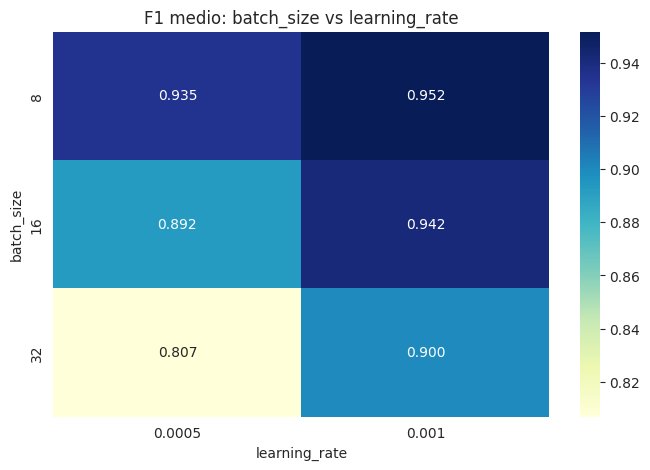

In [15]:
pivot = completed.pivot_table(
    index="batch_size",
    columns="learning_rate",
    values="best_val_token_f1_micro",
    aggfunc="mean",
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("F1 medio: batch_size vs learning_rate")
plt.ylabel("batch_size")
plt.xlabel("learning_rate")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "heatmap_batch_lr_f1.png", dpi=180)
plt.show()

## 6. Conclusiones rapidas


In [16]:
top5 = ranking.head(5)[
    [
        "batch_size",
        "epochs",
        "learning_rate",
        "freeze_backbone",
        "best_epoch",
        "best_val_token_f1_micro",
        "best_val_loss",
    ]
]
top5

,batch_size,epochs,learning_rate,freeze_backbone,best_epoch,best_val_token_f1_micro,best_val_loss
0,32,8,0.0010,False,6,0.983058,0.082086
1,32,16,0.0010,False,6,0.983058,0.082086
2,16,16,0.0010,False,12,0.977308,0.109111
3,32,8,0.0005,False,7,0.977023,0.084120
4,32,16,0.0005,False,7,0.977023,0.084120


In [17]:
print("Mejor opcion por F1:")
print(top5.iloc[0].to_string())

summary_lines = [
    "# Analisis NER",
    f"- Configuraciones registradas: {len(results)}",
    f"- Configuraciones completadas: {len(completed)}",
    f"- Mejor batch_size: {best['batch_size']}",
    f"- Mejor epochs: {best['epochs']}",
    f"- Mejor learning_rate: {best['learning_rate']}",
    f"- Mejor freeze_backbone: {best['freeze_backbone']}",
    f"- Mejor best_epoch: {best['best_epoch']}",
    f"- Mejor val_token_f1_micro: {best['best_val_token_f1_micro']:.6f}",
    f"- Mejor val_loss: {best['best_val_loss']:.6f}",
]
(OUTPUT_DIR / "summary.md").write_text("\n".join(summary_lines) + "\n", encoding="utf-8")
print("\nSugerencia: elegir la configuracion con mayor val_token_f1_micro y usar val_loss como desempate.")
print(f"Resumen guardado en {OUTPUT_DIR / "summary.md"}")


Mejor opcion por F1:
batch_size                       32
epochs                            8
learning_rate                 0.001
freeze_backbone               False
best_epoch                        6
best_val_token_f1_micro    0.983058
best_val_loss              0.082086

Sugerencia: elegir la configuracion con mayor val_token_f1_micro y usar val_loss como desempate.
